# 01 — Inspect and prepare Egyptian car listings

Milestone 1 of the Egyptian car pricer. Same idea as Week 7 Day 2: turn raw listings into `prompt` / `completion` splits for SFT.

This notebook does **not** train a model and does **not** push to the Hugging Face Hub.

**What you will do**
1. Load Hub train + validation from [mo-hug-me/Egyptian_cars_price_prediction](https://huggingface.co/datasets/mo-hug-me/Egyptian_cars_price_prediction) (the Hub test split is unlabeled)
2. Parse structured fields out of the already-formatted prompt
3. Apply the v1 filter rules and watch how many rows each rule drops
4. Split train / val / test (1,000 val, 1,000 test, stratified by brand)
5. Save locally under `data/` (gitignored)

Prices stay in **EGP**. We do not scrape Hatla2ee or OLX.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
from dotenv import load_dotenv
from huggingface_hub import login
import os

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

from pricer.items import PREFIX
from pricer.prep import (
    LITE_TRAIN_SIZE,
    SOURCE_DATASET,
    TEST_SIZE,
    VAL_SIZE,
    apply_hard_filters,
    apply_price_outliers,
    drop_exact_duplicates,
    lite_train,
    load_source,
    parse_frame,
    save_splits,
    split_frame,
)

load_dotenv(ROOT / ".env", override=True)
token = os.getenv("HF_TOKEN")
if token:
    login(token, add_to_git_credential=False)
    print("Logged in to Hugging Face")
else:
    print("No HF_TOKEN in .env — loading the public dataset anonymously")

e:\AI_Projects\egyptian-car-pricer\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


Logged in to Hugging Face


## 1. Load the source dataset

The Hub file is already in Week 7 SFT shape: `prompt`, `completion`, `text`. It ships three splits. We pool **train** (14,734) and **validation** (4,999). The Hub **test** split is 4,999 rows whose `completion` is `0` on every row, so there is no asking price to learn and that split is left out. Cleaning and our own 1,000 / 1,000 holdout happen after the pool, so an ad copied across Hub train and validation is deduped before it can land in both our train and test.

- **Train on** `prompt` + `completion`
- **Ignore** `text` for training (`text` is prompt + completion + `<|endoftext|>`)
- At inference the predictor must see only `prompt`, which ends with `Price is EGP`

In [2]:
raw = load_source()
print(f"Rows: {len(raw):,}   columns: {[c for c in raw.columns if c != 'hub_split']}")
print("\nHub splits:")
print(raw["hub_split"].value_counts().to_string())
print("\n--- prompt ---")
print(raw.iloc[0]["prompt"])
print("\n--- completion ---")
print(raw.iloc[0]["completion"])
print("\nPREFIX check:", raw.iloc[0]["prompt"].rstrip().endswith(PREFIX))

e:\AI_Projects\egyptian-car-pricer\.venv\Lib\site-packages\huggingface_hub\file_download.py:150: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Alaa\.cache\huggingface\hub\datasets--mo-hug-me--Egyptian_cars_price_prediction. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
e:\AI_Projects\egyptian-car-pricer\.venv\Lib\site-packages\huggingface_hub\file_downlo

Rows: 14,734   columns: ['prompt', 'completion', 'text']

--- prompt ---
What is the price of this car?

Brand: Volkswagen, Model: Tiguan, Year: 2023, Mileage: 28,000 km, Fuel: Gas, Transmission: Automatic, Description: Volkswagen Tiguan 2023

Price is EGP 

--- completion ---
1850000

PREFIX check: True


## 2. Parse fields out of the prompt

The ads look structured, but they are still strings. We regex out brand, model, year, mileage, fuel, transmission, then treat `completion` as the integer EGP price.

Rows that fail to parse are dropped (logged as `parse_failed`).

In [3]:
parsed, n_fail = parse_frame(raw)
print(f"Parsed {len(parsed):,}   failed {n_fail:,}")
display(parsed.head(3))
print("\nBrands:", parsed["brand"].nunique(), "  Models:", parsed["model"].nunique())
print("Year range:", parsed["year"].min(), "–", parsed["year"].max())
print("Price range: EGP", f"{parsed['price'].min():,.0f}", "–", f"{parsed['price'].max():,.0f}")
print("Fuel:", parsed["fuel"].value_counts().to_dict())
print("Transmission:", parsed["transmission"].value_counts().to_dict())

Parsed 14,618   failed 116


,brand,model,year,mileage,fuel,transmission,description,price,prompt,completion,gen_suspect
0,Volkswagen,Tiguan,2023,28000,Gas,Automatic,Volkswagen Tiguan 2023,1850000.0,What is the price of this car?\n\nBrand: Volks...,1850000,False
1,Volkswagen,ID 6,2022,94000,Electric,Automatic,Volkswagen ID 6 2022,1250000.0,What is the price of this car?\n\nBrand: Volks...,1250000,False
2,Byd,Song Plus,2025,0,Electric,Automatic,Byd Song Plus 2025,1350000.0,"What is the price of this car?\n\nBrand: Byd, ...",1350000,False



Brands: 120   Models: 901
Year range: 1966 – 2026
Price range: EGP 1 – 2,800,000,000
Fuel: {'Gas': 13441, 'Diesel': 527, 'Natural Gas': 267, 'Electric': 229, 'Hybrid': 154}
Transmission: {'Automatic': 11823, 'Manual': 2795}


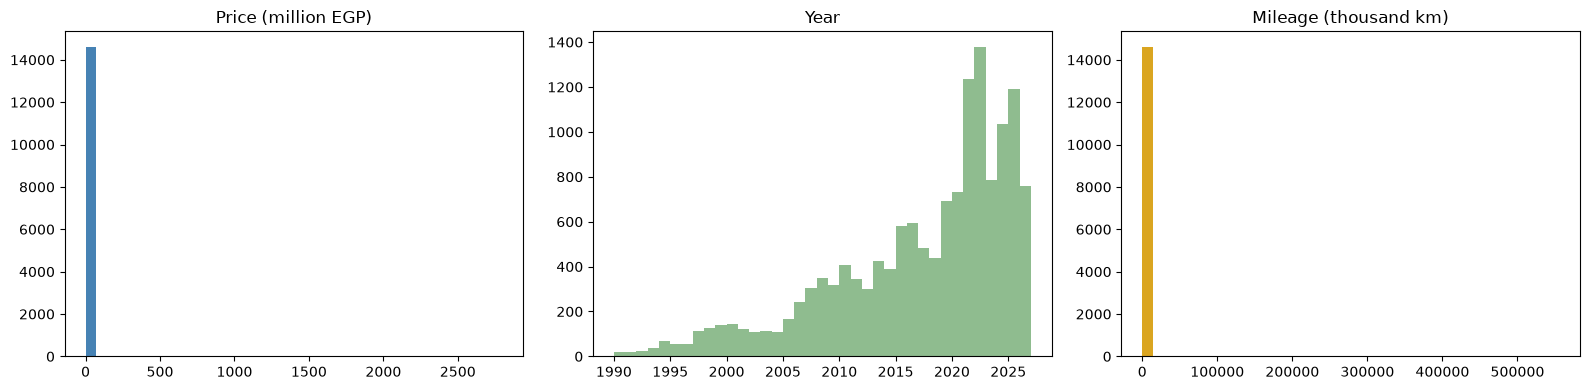

Top brands:
 brand
Hyundai       1321
Mercedes      1207
Kia           1043
Renault        812
Chevrolet      709
Nissan         687
BMW            628
Toyota         614
Peugeot        531
Opel           526
Fiat           514
Skoda          512
MG             510
Chery          450
Mitsubishi     437

Brand == Other: 10
Model == Other: 55
Mileage == 0: 3852
Mileage == 0 and year <= 2023: 1701
gen_suspect flags (kept for now): 87


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].hist(parsed["price"] / 1e6, bins=40, color="steelblue")
axes[0].set_title("Price (million EGP)")
axes[1].hist(parsed["year"], bins=range(1990, 2028), color="darkseagreen")
axes[1].set_title("Year")
axes[2].hist(parsed["mileage"] / 1000, bins=40, color="goldenrod")
axes[2].set_title("Mileage (thousand km)")
plt.tight_layout()
plt.show()

print("Top brands:\n", parsed["brand"].value_counts().head(15).to_string())
print("\nBrand == Other:", (parsed["brand"].str.casefold() == "other").sum())
print("Model == Other:", (parsed["model"].str.casefold() == "other").sum())
print("Mileage == 0:", (parsed["mileage"] == 0).sum())
print("Mileage == 0 and year <= 2023:", ((parsed["mileage"] == 0) & (parsed["year"] <= 2023)).sum())
print("gen_suspect flags (kept for now):", int(parsed["gen_suspect"].sum()))

## 3. Hard filters (applied one rule at a time in `apply_hard_filters`)

| Rule | Drop when |
|---|---|
| `other_brand_or_model` | Brand or Model is `Other` |
| `year_out_of_range` | Year not in 1990–2027 |
| `mileage_out_of_range` | Mileage &lt; 0 or &gt; 800,000 km |
| `price_global_clip` | Price &lt; 50,000 or &gt; 20,000,000 EGP |
| `zero_km_old_car` | Mileage is 0 **and** year ≤ 2023 |

0 km on a 2025/2026 car can be a new listing. 0 km on a 1998 Fiat is missing data.

Generation mismatches (Wrangler 4xe in 2017, Octavia A8 in 2015) are **flagged** as `gen_suspect`, not dropped in v1.

In [5]:
kept, dropped_hard = apply_hard_filters(parsed)
print("Hard-filter drop counts:")
print(dropped_hard["drop_reason"].value_counts().to_string() if len(dropped_hard) else "(none)")
print(f"\nStill kept: {len(kept):,} / {len(parsed):,}")

kept, n_dup = drop_exact_duplicates(kept)
print(f"Exact prompt+completion duplicates dropped: {n_dup:,}")
print(f"After dedup: {len(kept):,}")

Hard-filter drop counts:
drop_reason
zero_km_old_car         1517
year_out_of_range        224
price_global_clip        223
other_brand_or_model      56
mileage_out_of_range      24

Still kept: 12,574 / 14,618
Exact prompt+completion duplicates dropped: 37
After dedup: 12,537


## 4. Within-group price outliers

A 2023 Mercedes C 180 at 300,000 EGP is not a global clip problem — it is absurd **relative to other Mercedes C-class cars**.

- If `(brand, model, year)` has ≥ 8 rows: drop Tukey IQR outliers (`Q1 − 1.5 IQR`, `Q3 + 1.5 IQR`)
- Else if `(brand, model)` has ≥ 12 rows: drop prices outside `0.25×–4×` the model median

In [6]:
kept, dropped_out = apply_price_outliers(kept)
print(f"Price outliers dropped: {len(dropped_out):,}")
if len(dropped_out):
    show = dropped_out.sort_values("price").head(8)[
        ["brand", "model", "year", "mileage", "price"]
    ]
    display(show)
print(f"\nClean rows: {len(kept):,}")
print("gen_suspect still in the clean set:", int(kept["gen_suspect"].sum()))

Price outliers dropped: 376


,brand,model,year,mileage,price
10361,Renault,Logan,2019,182800,50000.0
5644,Fiat,Tipo,2024,0,50000.0
2350,Mitsubishi,Lancer Puma,2008,151000,55000.0
5477,Hyundai,Avante,2011,112000,62000.0
4696,Seat,Ibiza,1991,50000,70000.0
12086,Jac,S2,2024,0,74000.0
2860,Nissan,Sunny,2024,0,76000.0
9914,Ford,Fiesta,1996,250000,80000.0



Clean rows: 12,161
gen_suspect still in the clean set: 64


## 5. Train / val / test split

- **test = 1,000** (frozen for the Week 7-style Tester)
- **val = 1,000**
- **train = the rest** of the cleaned Hub train + validation rows
- Stratify by brand (rare brands with &lt; 5 rows are grouped)
- Seed `42`

`LITE_MODE` later uses 8,000 of these train rows, but **the same 1,000 test cars**.

In [7]:
train, val, test = split_frame(kept)
train_lite = lite_train(train, n=LITE_TRAIN_SIZE)

print(f"train      {len(train):,}")
print(f"train_lite {len(train_lite):,}   (LITE_MODE)")
print(f"val        {len(val):,}     (target {VAL_SIZE})")
print(f"test       {len(test):,}     (target {TEST_SIZE})")
print("\nTest brands (top):")
print(test["brand"].value_counts().head(10).to_string())
print("\nExample test prompt:\n")
print(test.iloc[0]["prompt"])
print("completion:", test.iloc[0]["completion"])

train      11,461
train_lite 8,000   (LITE_MODE)
val        500     (target 500)
test       200     (target 200)

Test brands (top):
brand
Hyundai      19
Mercedes     16
Kia          15
Renault      12
Chevrolet    10
Nissan       10
BMW           9
Toyota        8
Opel          8
Skoda         7

Example test prompt:

What is the price of this car?

Brand: Chevrolet, Model: Spark, Year: 2008, Mileage: 150,000 km, Fuel: Gas, Transmission: Manual, Description: Chevrolet Spark 2008

Price is EGP
completion: 230000


## 6. Save locally (no Hub push)

Writes parquet + a Hugging Face `DatasetDict` under `data/`. Those files are gitignored.

The next cell is **commented on purpose**. Uncomment `CarItem.push_prompts_to_hub(...)` only after you explicitly ask to publish.

In [8]:
report = {
    "source_dataset": SOURCE_DATASET,
    "source_rows": int(len(raw)),
    "hub_splits": {k: int(v) for k, v in raw["hub_split"].value_counts().to_dict().items()},
    "hub_test_skipped": 4999,
    "hub_test_skip_reason": "completion is 0 on every row",
    "parse_failed": int(n_fail),
    "hard_drop": dropped_hard["drop_reason"].value_counts().to_dict() if len(dropped_hard) else {},
    "exact_duplicates": int(n_dup),
    "price_outliers": int(len(dropped_out)),
    "kept": int(len(kept)),
    "gen_suspect_kept": int(kept["gen_suspect"].sum()),
    "splits": {
        "train": int(len(train)),
        "train_lite": int(len(train_lite)),
        "val": int(len(val)),
        "test": int(len(test)),
    },
}
out = save_splits(train, val, test, report, lite=train_lite, data_dir=ROOT / "data")
print("Wrote:", out)
print(pd.Series(report).to_string())

# Do not push unless asked:
# from pricer.items import CarItem
# from pricer.prep import to_items
# CarItem.push_prompts_to_hub("YOUR_USER/egyptian-cars-prompts", to_items(train), to_items(val), to_items(test))

Saving the dataset (1/1 shards): 100%|██████████| 200/200 [00:00<00:00, 37377.39 examples/s]

Wrote: e:\AI_Projects\egyptian-car-pricer\data
source_dataset               mo-hug-me/Egyptian_cars_price_prediction
source_rows                                                     14734
parse_failed                                                      116
hard_drop           {'zero_km_old_car': 1517, 'year_out_of_range':...
exact_duplicates                                                   37
price_outliers                                                    376
kept                                                            12161
gen_suspect_kept                                                   64
splits              {'train': 11461, 'train_lite': 8000, 'val': 50...
